# Avance 2: Ingeniería de Características
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

Este notebook implementa la fase de Ingeniería de Características (Feature Engineering) sobre el dataset unificado de vacunación y casos de sarampión en México (2010-2023).

## 1. Importación de Librerías y Carga de Datos

### Contexto del Dataset

El dataset `dataset_sarampion_vacunas_2010-2023.csv` utilizado en este notebook fue construido mediante un proceso de preparación de datos en tres etapas documentado en los siguientes scripts:

**📋 Scripts de Preparación de Datos:**

1. **[DataPreparation_1_ScriptUnificadorDatasetBoletinanios.ipynb](Data%20Preparation/DataPreparation_1_ScriptUnificadorDatasetBoletinanios.ipynb)**
   - Unificación de 25 archivos CSV del Boletín Epidemiológico (2000-2025)
   - Consolidación de datos semanales de incidencia de sarampión
   - Normalización de columnas y manejo de inconsistencias de formato

2. **[DataPreparation_2_ScriptUnificadorDatasetDosisanios.ipynb](Data%20Preparation/DataPreparation_2_ScriptUnificadorDatasetDosisanios.ipynb)**
   - Unificación de archivos de dosis de vacuna SRP (2010-2023)
   - Agregación mensual de dosis administradas por año

3. **[DataPreparation_3_UnificadorDatasetsIncidenciasyVacunas.ipynb](Data%20Preparation/DataPreparation_3_UnificadorDatasetsIncidenciasyVacunas.ipynb)**
   - Conversión de incidencia semanal a mensual (4-5 semanas/mes)
   - Unión (merge) de datasets de vacunación e incidencia de sarampión
   - Filtrado del período 2010-2023 para concordancia temporal
   - **Resultado:** 168 registros (14 años × 12 meses) con 4 columnas: `anio`, `mes`, `total_dosis`, `casos_sarampion`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_regression
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [2]:
# Configurar rutas
base_path = Path.cwd().parent
data_path = base_path / 'data' / 'processed'

# Cargar dataset preparado
df = pd.read_csv(data_path / 'dataset_sarampion_vacunas_2010-2023.csv')

print("="*70)
print("DATASET CARGADO")
print("="*70)
print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeros registros:")
print(df.head(10))
print(f"\nInformación del dataset:")
print(df.info())
print(f"\nEstadísticas descriptivas:")
print(df.describe())

DATASET CARGADO
Shape: (168, 4)

Columnas: ['mes', 'anio', 'total_dosis', 'casos_sarampion']

Primeros registros:
   mes  anio  total_dosis  casos_sarampion
0    1  2010       180830                0
1    2  2010       183377                0
2    3  2010       242572                0
3    4  2010       216429                0
4    5  2010       174559                0
5    6  2010       411045                0
6    7  2010       229487               81
7    8  2010       254698               25
8    9  2010       206088                0
9   10  2010       396236               15

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mes              168 non-null    int64
 1   anio             168 non-null    int64
 2   total_dosis      168 non-null    int64
 3   casos_sarampion  168 non-null    int64
dtypes: int64(4)
me

## 2. Generación de Nuevas Características

### Justificación:
Crearemos características derivadas que capturen patrones temporales, estacionales y epidemiológicos relevantes para el análisis de sarampión:

La generación de características permite representar mejor relaciones subyacentes en los datos y mejorar el desempeño del modelo sin necesidad de más datos

1. **Características temporales cíclicas**: Representación sinusoidal de mes y año para capturar estacionalidad
2. **Indicadores de estacionalidad**: Temporadas del año que afectan la transmisión de enfermedades
3. **Métricas de ventana móvil**: Tendencias recientes en vacunación y casos
4. **Tasas y proporciones**: Incidencia relativa y eficiencia de vacunación
5. **Características de retraso (lag)**: Valores históricos para análisis de series temporales

In [3]:
# Crear copia para feature engineering
df_fe = df.copy()

print("="*70)
print("GENERACIÓN DE NUEVAS CARACTERÍSTICAS")
print("="*70)

# 1. CARACTERÍSTICAS TEMPORALES CÍCLICAS
print("\n1. Características temporales cíclicas...")
# Justificación: Los patrones estacionales son cíclicos, no lineales
# El uso de seno y coseno permite al modelo capturar la naturaleza circular del tiempo
df_fe['mes_sin'] = np.sin(2 * np.pi * df_fe['mes'] / 12)
df_fe['mes_cos'] = np.cos(2 * np.pi * df_fe['mes'] / 12)
df_fe['anio_normalizado'] = (df_fe['anio'] - df_fe['anio'].min()) / (df_fe['anio'].max() - df_fe['anio'].min())
print("   ✓ mes_sin, mes_cos, anio_normalizado")

# 2. INDICADORES DE ESTACIONALIDAD
print("\n2. Indicadores de estacionalidad...")
# Justificación: El sarampión muestra patrones estacionales bien documentados
# Mayor transmisión en invierno-primavera por mayor contacto en espacios cerrados
df_fe['trimestre'] = df_fe['mes'].apply(lambda x: (x-1)//3 + 1)
df_fe['es_invierno'] = df_fe['mes'].isin([12, 1, 2]).astype(int)
df_fe['es_primavera'] = df_fe['mes'].isin([3, 4, 5]).astype(int)
df_fe['es_verano'] = df_fe['mes'].isin([6, 7, 8]).astype(int)
df_fe['es_otonio'] = df_fe['mes'].isin([9, 10, 11]).astype(int)
df_fe['temporada_alta_casos'] = df_fe['mes'].isin([1, 2, 3, 4, 5]).astype(int)  # Invierno-Primavera
print("   ✓ trimestre, estaciones del año, temporada_alta_casos")

# 3. CARACTERÍSTICAS DE VENTANA MÓVIL (ROLLING)
print("\n3. Características de ventana móvil...")
# Justificación: Las tendencias recientes son más predictivas que valores puntuales
# Ventanas de 3 y 6 meses capturan tendencias trimestrales y semestrales
df_fe['dosis_rolling_mean_3m'] = df_fe['total_dosis'].rolling(window=3, min_periods=1).mean()
df_fe['dosis_rolling_mean_6m'] = df_fe['total_dosis'].rolling(window=6, min_periods=1).mean()
df_fe['dosis_rolling_std_3m'] = df_fe['total_dosis'].rolling(window=3, min_periods=1).std().fillna(0)
df_fe['casos_rolling_mean_3m'] = df_fe['casos_sarampion'].rolling(window=3, min_periods=1).mean()
df_fe['casos_rolling_mean_6m'] = df_fe['casos_sarampion'].rolling(window=6, min_periods=1).mean()
print("   ✓ Medias móviles y desviación estándar (3 y 6 meses)")

# 4. CARACTERÍSTICAS DE RETRASO (LAG)
print("\n4. Características de retraso (lag)...")
# Justificación: El impacto de la vacunación no es inmediato
# Período de incubación del sarampión: 10-14 días, efectos poblacionales observables en 1-3 meses
for lag in [1, 2, 3, 6]:
    df_fe[f'dosis_lag_{lag}m'] = df_fe['total_dosis'].shift(lag).fillna(df_fe['total_dosis'].mean())
    df_fe[f'casos_lag_{lag}m'] = df_fe['casos_sarampion'].shift(lag).fillna(0)
print("   ✓ Lags de 1, 2, 3 y 6 meses para dosis y casos")

# 5. TASAS Y PROPORCIONES
print("\n5. Tasas y proporciones...")
# Justificación: Las tasas relativas son más informativas que valores absolutos
# Capturan eficiencia y tendencias independientes de la escala
df_fe['tasa_casos_por_millon_dosis'] = (df_fe['casos_sarampion'] / (df_fe['total_dosis'] / 1_000_000)).replace([np.inf, -np.inf], 0)
df_fe['cambio_dosis_mes_anterior'] = df_fe['total_dosis'].pct_change().fillna(0)
df_fe['cambio_casos_mes_anterior'] = df_fe['casos_sarampion'].pct_change().fillna(0).replace([np.inf, -np.inf], 0)
df_fe['dosis_vs_media_anual'] = df_fe.groupby('anio')['total_dosis'].transform(lambda x: (x - x.mean()) / x.std()).fillna(0)
print("   ✓ Tasas de casos, cambios porcentuales, z-scores anuales")

# 6. CARACTERÍSTICAS AGREGADAS ANUALES
print("\n6. Características agregadas anuales...")
# Justificación: El contexto anual ayuda a identificar años problemáticos o exitosos
df_fe['dosis_total_anual'] = df_fe.groupby('anio')['total_dosis'].transform('sum')
df_fe['casos_total_anual'] = df_fe.groupby('anio')['casos_sarampion'].transform('sum')
df_fe['mes_en_anio'] = df_fe.groupby('anio').cumcount() + 1
print("   ✓ Totales anuales, posición del mes en el año")

# 7. CARACTERÍSTICAS DE INTERACCIÓN
print("\n7. Características de interacción...")
# Justificación: Las interacciones capturan efectos no lineales entre variables
df_fe['dosis_x_temporada_alta'] = df_fe['total_dosis'] * df_fe['temporada_alta_casos']
df_fe['dosis_x_trimestre'] = df_fe['total_dosis'] * df_fe['trimestre']
print("   ✓ Interacciones dosis-temporada")

print(f"\n{'='*70}")
print(f"RESUMEN: {len(df_fe.columns) - len(df.columns)} nuevas características creadas")
print(f"Total de características: {len(df_fe.columns)}")
print(f"{'='*70}")

# Mostrar las nuevas características
nuevas_cols = [col for col in df_fe.columns if col not in df.columns]
print(f"\nNuevas características creadas:")
for i, col in enumerate(nuevas_cols, 1):
    print(f"{i:2d}. {col}")

print(f"\nPrimeros registros con nuevas características:")
print(df_fe[nuevas_cols[:5]].head())

GENERACIÓN DE NUEVAS CARACTERÍSTICAS

1. Características temporales cíclicas...
   ✓ mes_sin, mes_cos, anio_normalizado

2. Indicadores de estacionalidad...
   ✓ trimestre, estaciones del año, temporada_alta_casos

3. Características de ventana móvil...
   ✓ Medias móviles y desviación estándar (3 y 6 meses)

4. Características de retraso (lag)...
   ✓ Lags de 1, 2, 3 y 6 meses para dosis y casos

5. Tasas y proporciones...
   ✓ Tasas de casos, cambios porcentuales, z-scores anuales

6. Características agregadas anuales...
   ✓ Totales anuales, posición del mes en el año

7. Características de interacción...
   ✓ Interacciones dosis-temporada

RESUMEN: 31 nuevas características creadas
Total de características: 35

Nuevas características creadas:
 1. mes_sin
 2. mes_cos
 3. anio_normalizado
 4. trimestre
 5. es_invierno
 6. es_primavera
 7. es_verano
 8. es_otonio
 9. temporada_alta_casos
10. dosis_rolling_mean_3m
11. dosis_rolling_mean_6m
12. dosis_rolling_std_3m
13. casos_rolling_mea

## 3. Codificación de Variables Categóricas

### Justificación:
- **One-Hot Encoding** para trimestre: No existe orden jerárquico entre trimestres
- Las estaciones ya están codificadas como variables binarias (0/1)
- No aplicamos Label Encoding porque nuestras variables categóricas no tienen orden natural

Los algoritmos de ML requieren datos numéricos; la codificación evita introducir relaciones artificiales


In [4]:
print("="*70)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*70)

# One-Hot Encoding para trimestre
print("\nAplicando One-Hot Encoding a 'trimestre'...")
df_encoded = pd.get_dummies(df_fe, columns=['trimestre'], prefix='Q', drop_first=True)
print(f"✓ Trimestre codificado (3 variables dummy)")

print(f"\nShape después de codificación: {df_encoded.shape}")
print(f"\nColumnas agregadas: {[col for col in df_encoded.columns if col.startswith('Q_')]}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Aplicando One-Hot Encoding a 'trimestre'...
✓ Trimestre codificado (3 variables dummy)

Shape después de codificación: (168, 37)

Columnas agregadas: ['Q_2', 'Q_3', 'Q_4']


## 4. Análisis de Distribuciones y Transformaciones

### Justificación:
Analizaremos las distribuciones de las variables numéricas para determinar si requieren transformaciones:
- **Variables con distribución sesgada** → Transformación logarítmica o Box-Cox
- **Variables con outliers extremos** → Transformación robusta o Yeo-Johnson
- **Test de normalidad** → Shapiro-Wilk para confirmar necesidad de transformación

ANÁLISIS DE DISTRIBUCIONES


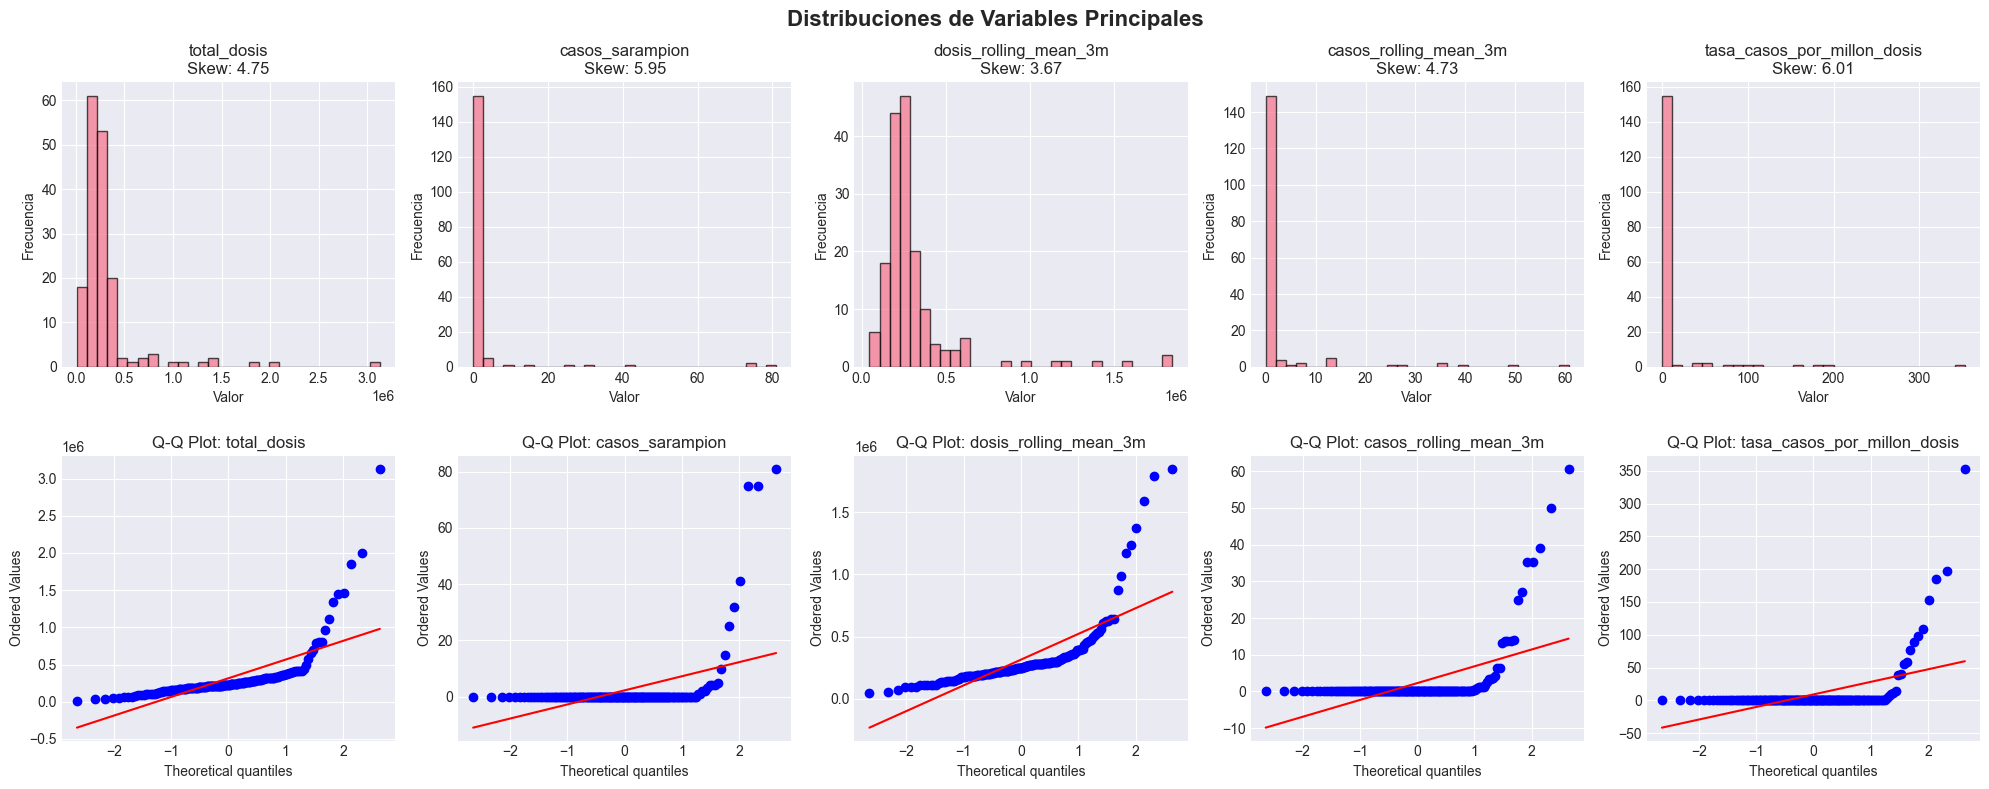


Test de Shapiro-Wilk (H0: datos siguen distribución normal):
----------------------------------------------------------------------
total_dosis                         | p-value: 0.000000 | NO normal
casos_sarampion                     | p-value: 0.000000 | NO normal
dosis_rolling_mean_3m               | p-value: 0.000391 | NO normal
casos_rolling_mean_3m               | p-value: 0.000000 | NO normal
tasa_casos_por_millon_dosis         | p-value: 0.000000 | NO normal


In [5]:
print("="*70)
print("ANÁLISIS DE DISTRIBUCIONES")
print("="*70)

# Variables numéricas principales para analizar
vars_principales = ['total_dosis', 'casos_sarampion', 'dosis_rolling_mean_3m', 
                    'casos_rolling_mean_3m', 'tasa_casos_por_millon_dosis']

# Análisis de distribución
fig, axes = plt.subplots(2, len(vars_principales), figsize=(20, 8))
fig.suptitle('Distribuciones de Variables Principales', fontsize=16, fontweight='bold')

for i, var in enumerate(vars_principales):
    # Histograma
    axes[0, i].hist(df_encoded[var], bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{var}\nSkew: {df_encoded[var].skew():.2f}')
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')
    
    # Q-Q Plot
    stats.probplot(df_encoded[var], dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot: {var}')

plt.tight_layout()
plt.show()

# Test de normalidad
print("\nTest de Shapiro-Wilk (H0: datos siguen distribución normal):")
print("-" * 70)
for var in vars_principales:
    stat, p_value = stats.shapiro(df_encoded[var][:50])  # Muestra de 50 para Shapiro
    print(f"{var:35s} | p-value: {p_value:.6f} | {'NO normal' if p_value < 0.05 else 'Normal'}")

**Interpretación de Resultados:**

Los histogramas y Q-Q plots revelan que todas las variables principales presentan **distribuciones no normales** (confirmado por Shapiro-Wilk con p<0.05). Se observa sesgo positivo significativo (skewness de 4.75 a 6.01), con concentración de valores bajos y colas largas hacia la derecha. Los Q-Q plots muestran desviaciones de la línea teórica, especialmente en los extremos, evidenciando la necesidad de aplicar transformaciones para normalizar las distribuciones antes del modelado.

## 5. Aplicación de Transformaciones

### Justificación de Transformaciones Seleccionadas:

1. **Yeo-Johnson**: Seleccionada sobre Box-Cox porque:
   - Maneja valores cero y negativos (común en casos_sarampion y cambios porcentuales)
   - Más robusta para nuestro dataset con alta variabilidad
   
2. **Logarítmica (log1p)**: Para variables con sesgo positivo extremo
   - Reduce el impacto de valores atípicos altos
   - Preserva ceros mediante log(x+1)
Reduce asimetría, estabiliza varianza y mejora el rendimiento de modelos sensibles a la normalidad


In [6]:
from sklearn.preprocessing import PowerTransformer

print("="*70)
print("APLICACIÓN DE TRANSFORMACIONES")
print("="*70)

df_transformed = df_encoded.copy()

# 1. TRANSFORMACIÓN YEO-JOHNSON
print("\n1. Transformación Yeo-Johnson...")
print("   Justificación: Maneja valores cero/negativos, normaliza distribuciones sesgadas")

vars_yeo_johnson = ['total_dosis', 'dosis_rolling_mean_3m', 'dosis_rolling_mean_6m',
                    'dosis_rolling_std_3m', 'dosis_total_anual']

pt = PowerTransformer(method='yeo-johnson', standardize=False)
for var in vars_yeo_johnson:
    df_transformed[f'{var}_yj'] = pt.fit_transform(df_transformed[[var]])
    print(f"   ✓ {var} → {var}_yj | Skew: {df_transformed[var].skew():.2f} → {df_transformed[f'{var}_yj'].skew():.2f}")

# 2. TRANSFORMACIÓN LOGARÍTMICA
print("\n2. Transformación Logarítmica (log1p)...")
print("   Justificación: Reduce sesgo y estabiliza varianza en conteos")

vars_log = ['casos_sarampion', 'casos_rolling_mean_3m', 'casos_rolling_mean_6m', 'casos_total_anual']
for var in vars_log:
    df_transformed[f'{var}_log'] = np.log1p(df_transformed[var])
    print(f"   ✓ {var} → {var}_log | Skew: {df_transformed[var].skew():.2f} → {df_transformed[f'{var}_log'].skew():.2f}")

# 3. TRANSFORMACIÓN RAÍZ CUADRADA
print("\n3. Transformación Raíz Cuadrada...")
print("   Justificación: Alternativa más suave que log para datos de conteo")

df_transformed['casos_sarampion_sqrt'] = np.sqrt(df_transformed['casos_sarampion'])
print(f"   ✓ casos_sarampion → casos_sarampion_sqrt")

print(f"\n{'='*70}")
print(f"Total de variables transformadas: {len([col for col in df_transformed.columns if col.endswith(('_yj', '_log', '_sqrt'))])}")
print(f"Shape del dataset: {df_transformed.shape}")
print(f"{'='*70}")

APLICACIÓN DE TRANSFORMACIONES

1. Transformación Yeo-Johnson...
   Justificación: Maneja valores cero/negativos, normaliza distribuciones sesgadas
   ✓ total_dosis → total_dosis_yj | Skew: 4.75 → -0.02
   ✓ dosis_rolling_mean_3m → dosis_rolling_mean_3m_yj | Skew: 3.67 → -0.09
   ✓ dosis_rolling_mean_6m → dosis_rolling_mean_6m_yj | Skew: 2.55 → -0.07
   ✓ dosis_rolling_std_3m → dosis_rolling_std_3m_yj | Skew: 3.72 → 0.22
   ✓ dosis_total_anual → dosis_total_anual_yj | Skew: 1.45 → 0.01

2. Transformación Logarítmica (log1p)...
   Justificación: Reduce sesgo y estabiliza varianza en conteos
   ✓ casos_sarampion → casos_sarampion_log | Skew: 5.95 → 3.80
   ✓ casos_rolling_mean_3m → casos_rolling_mean_3m_log | Skew: 4.73 → 2.82
   ✓ casos_rolling_mean_6m → casos_rolling_mean_6m_log | Skew: 3.37 → 2.13
   ✓ casos_total_anual → casos_total_anual_log | Skew: 2.12 → 1.04

3. Transformación Raíz Cuadrada...
   Justificación: Alternativa más suave que log para datos de conteo
   ✓ casos_sarampi

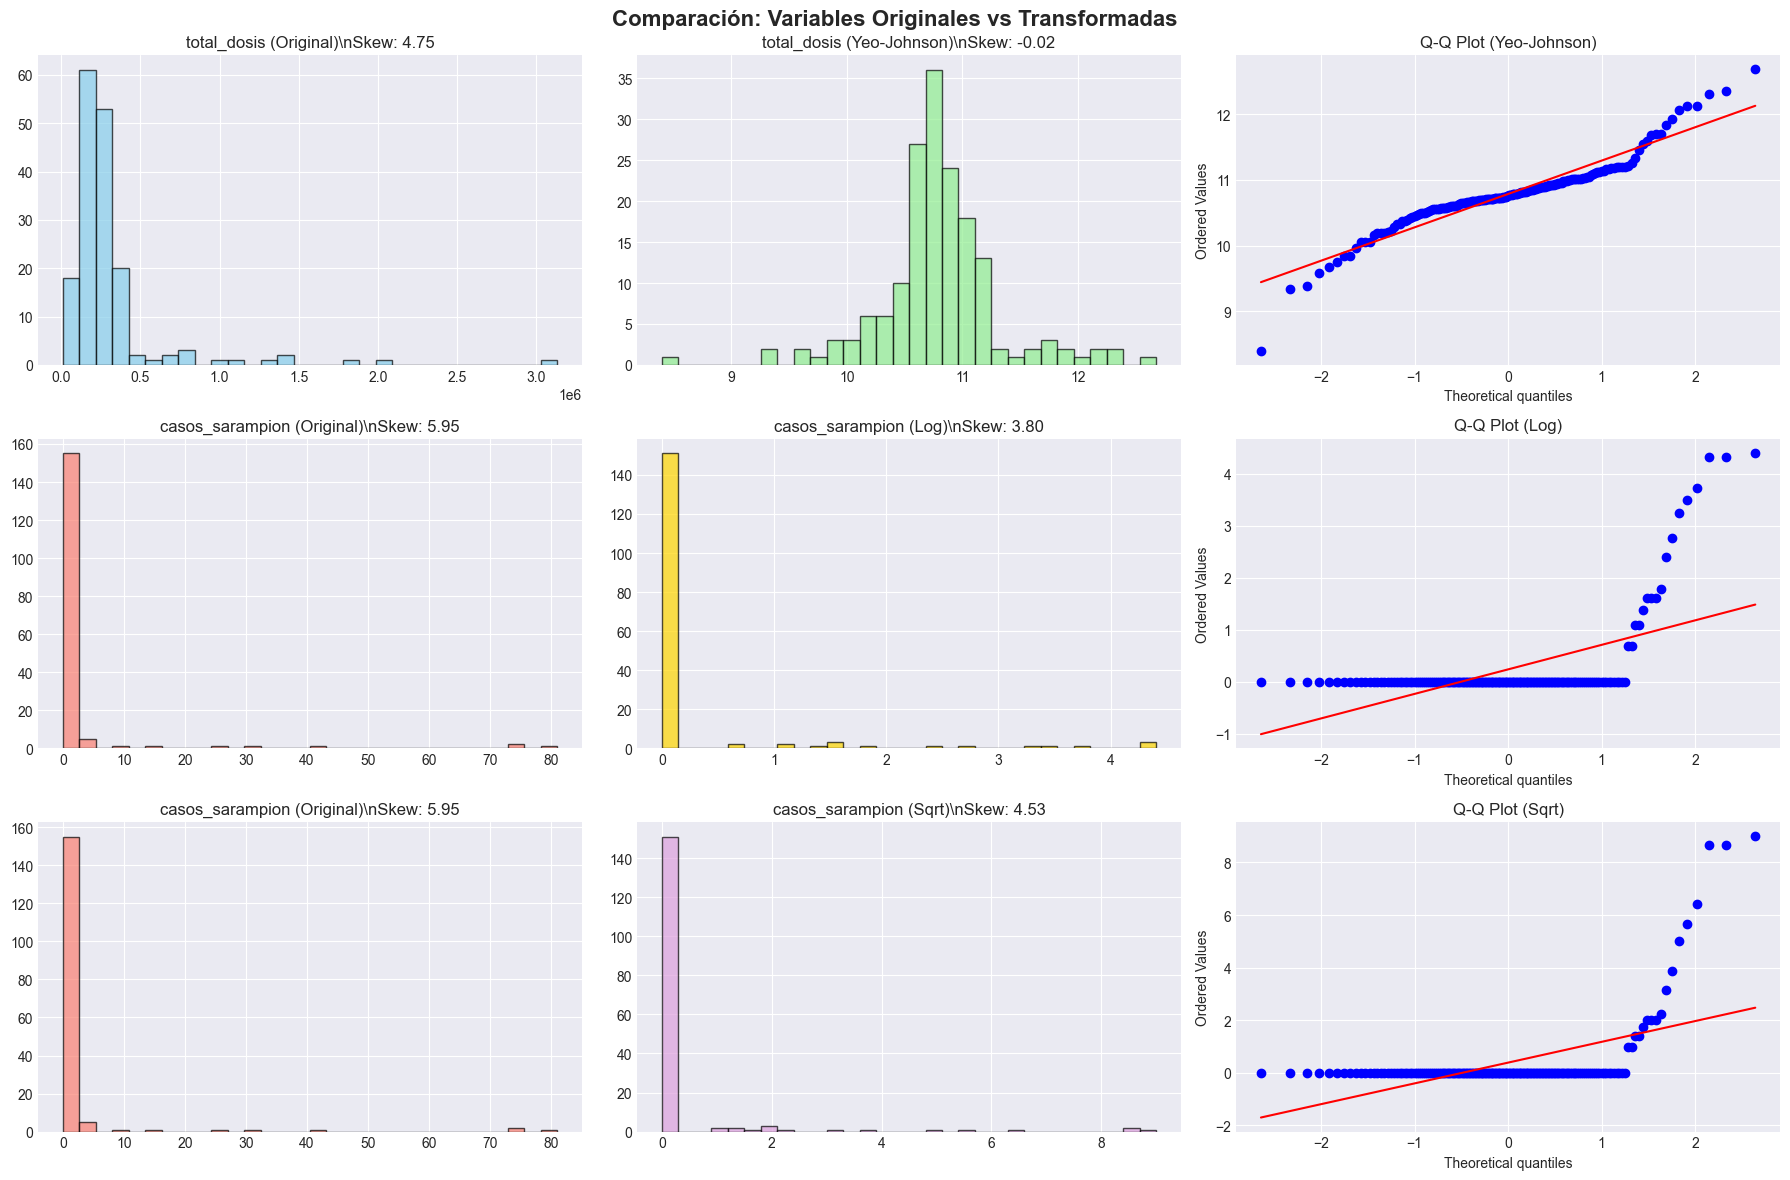

In [7]:
# Visualización comparativa de transformaciones
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Comparación: Variables Originales vs Transformadas', fontsize=16, fontweight='bold')

# Ejemplo 1: total_dosis
axes[0, 0].hist(df_transformed['total_dosis'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title(f'total_dosis (Original)\\nSkew: {df_transformed["total_dosis"].skew():.2f}')
axes[0, 1].hist(df_transformed['total_dosis_yj'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title(f'total_dosis (Yeo-Johnson)\\nSkew: {df_transformed["total_dosis_yj"].skew():.2f}')
stats.probplot(df_transformed['total_dosis_yj'], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Yeo-Johnson)')

# Ejemplo 2: casos_sarampion
axes[1, 0].hist(df_transformed['casos_sarampion'], bins=30, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 0].set_title(f'casos_sarampion (Original)\\nSkew: {df_transformed["casos_sarampion"].skew():.2f}')
axes[1, 1].hist(df_transformed['casos_sarampion_log'], bins=30, edgecolor='black', alpha=0.7, color='gold')
axes[1, 1].set_title(f'casos_sarampion (Log)\\nSkew: {df_transformed["casos_sarampion_log"].skew():.2f}')
stats.probplot(df_transformed['casos_sarampion_log'], dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot (Log)')

# Ejemplo 3: casos_sarampion (sqrt)
axes[2, 0].hist(df_transformed['casos_sarampion'], bins=30, edgecolor='black', alpha=0.7, color='salmon')
axes[2, 0].set_title(f'casos_sarampion (Original)\\nSkew: {df_transformed["casos_sarampion"].skew():.2f}')
axes[2, 1].hist(df_transformed['casos_sarampion_sqrt'], bins=30, edgecolor='black', alpha=0.7, color='plum')
axes[2, 1].set_title(f'casos_sarampion (Sqrt)\\nSkew: {df_transformed["casos_sarampion_sqrt"].skew():.2f}')
stats.probplot(df_transformed['casos_sarampion_sqrt'], dist="norm", plot=axes[2, 2])
axes[2, 2].set_title('Q-Q Plot (Sqrt)')

plt.tight_layout()
plt.show()

**Evaluación de Transformaciones:**

Las visualizaciones demuestran la efectividad de las transformaciones aplicadas:

- **Yeo-Johnson** en `total_dosis` reduce el skewness de 4.75 a -0.02, logrando una distribución casi perfectamente simétrica con Q-Q plot muy cercano a la línea teórica.
- **Logarítmica (log1p)** en `casos_sarampion` reduce el skewness de 5.95 a 3.80, mejorando sustancialmente la simetría, aunque persiste cierta asimetría por la concentración de ceros.
- **Raíz cuadrada (sqrt)** en `casos_sarampion` ofrece una alternativa más suave con skewness de 4.53, útil para preservar más información de los valores pequeños.

Las tres transformaciones mejoran notablemente la aproximación a normalidad, siendo Yeo-Johnson la más efectiva.

## 6. Escalamiento de Variables

### Justificación de Métodos de Escalamiento:

1. **StandardScaler (Z-score)**: 
   - Para variables transformadas que siguen distribución normal
   - Media = 0, Desviación estándar = 1
   - Óptimo para algoritmos sensibles a escala (SVM, KNN, Redes Neuronales)

2. **MinMaxScaler**: 
   - Para variables acotadas naturalmente (proporciones, porcentajes)
   - Escala a rango [0, 1]
   - Preserva forma de distribución original

3. **RobustScaler**: 
   - Para variables con outliers
   - Usa mediana y rango intercuartílico (IQR)
   - Más robusto que StandardScaler ante valores atípicos

Evita que variables con mayor magnitud dominen el modelo y mejora la convergencia en algoritmos como Regresión, SVM y KNN

In [8]:
print("="*70)
print("ESCALAMIENTO DE VARIABLES")
print("="*70)

df_scaled = df_transformed.copy()

# 1. STANDARDSCALER (para variables transformadas)
print("\n1. StandardScaler (Z-score normalization)...")
print("   Aplicado a: Variables transformadas con Yeo-Johnson y Log")

scaler_standard = StandardScaler()
vars_standard = [col for col in df_scaled.columns if col.endswith(('_yj', '_log'))]

df_scaled[[f'{col}_scaled' for col in vars_standard]] = scaler_standard.fit_transform(df_scaled[vars_standard])
print(f"   ✓ {len(vars_standard)} variables escaladas con StandardScaler")

# 2. MINMAXSCALER (para proporciones y características acotadas)
print("\n2. MinMaxScaler [0,1]...")
print("   Aplicado a: Características temporales cíclicas y proporciones")

scaler_minmax = MinMaxScaler()
vars_minmax = ['mes_sin', 'mes_cos', 'anio_normalizado', 'cambio_dosis_mes_anterior', 
               'cambio_casos_mes_anterior', 'tasa_casos_por_millon_dosis']

df_scaled[[f'{col}_minmax' for col in vars_minmax]] = scaler_minmax.fit_transform(df_scaled[vars_minmax])
print(f"   ✓ {len(vars_minmax)} variables escaladas con MinMaxScaler")

# 3. ROBUSTSCALER (para variables con outliers)
print("\n3. RobustScaler (basado en mediana e IQR)...")
print("   Aplicado a: Variables originales con posibles outliers")

scaler_robust = RobustScaler()
vars_robust = ['total_dosis', 'casos_sarampion', 'dosis_rolling_std_3m']

df_scaled[[f'{col}_robust' for col in vars_robust]] = scaler_robust.fit_transform(df_scaled[vars_robust])
print(f"   ✓ {len(vars_robust)} variables escaladas con RobustScaler")

print(f"\n{'='*70}")
print(f"Total de variables escaladas: {len([col for col in df_scaled.columns if col.endswith(('_scaled', '_minmax', '_robust'))])}")
print(f"Shape del dataset: {df_scaled.shape}")
print(f"{'='*70}")

# Verificar escalamiento
print("\nVerificación de escalamiento (primeras 5 variables StandardScaler):")
for col in [f'{col}_scaled' for col in vars_standard[:5]]:
    print(f"{col:45s} | Media: {df_scaled[col].mean():7.4f} | Std: {df_scaled[col].std():7.4f}")

ESCALAMIENTO DE VARIABLES

1. StandardScaler (Z-score normalization)...
   Aplicado a: Variables transformadas con Yeo-Johnson y Log
   ✓ 9 variables escaladas con StandardScaler

2. MinMaxScaler [0,1]...
   Aplicado a: Características temporales cíclicas y proporciones
   ✓ 6 variables escaladas con MinMaxScaler

3. RobustScaler (basado en mediana e IQR)...
   Aplicado a: Variables originales con posibles outliers
   ✓ 3 variables escaladas con RobustScaler

Total de variables escaladas: 18
Shape del dataset: (168, 65)

Verificación de escalamiento (primeras 5 variables StandardScaler):
total_dosis_yj_scaled                         | Media: -0.0000 | Std:  1.0030
dosis_rolling_mean_3m_yj_scaled               | Media:  0.0000 | Std:  1.0030
dosis_rolling_mean_6m_yj_scaled               | Media:  0.0000 | Std:  1.0030
dosis_rolling_std_3m_yj_scaled                | Media:  0.0000 | Std:  1.0030
dosis_total_anual_yj_scaled                   | Media: -0.0000 | Std:  1.0030


## 7. Selección de Características - Métodos de Filtrado

### Métodos Aplicados:

1. **Umbral de Varianza**: Elimina características con varianza cercana a cero
2. **Correlación de Pearson**: Identifica relaciones lineales con la variable objetivo
3. **ANOVA F-test**: Evalúa diferencias significativas entre grupos
4. **Mutual Information**: Captura relaciones no lineales

Total de características numéricas candidatas: 59
(Varianza) Seleccionadas: 57
(Correlación) Seleccionadas (|r|>=0.2): 16
(ANOVA) Top-20 seleccionadas: 20
(Mutual Information) Seleccionadas: 20
Características en consenso (>=2 métodos): 23


,feature,count_methods,corr,anova_score,mi
casos_lag_1m,casos_lag_1m,4,0.4652,4.5852e+01,0.0762
casos_rolling_mean_3m,casos_rolling_mean_3m,4,0.7051,1.6416e+02,0.1474
tasa_casos_por_millon_dosis,tasa_casos_por_millon_dosis,4,0.8461,4.1834e+02,0.2277
casos_sarampion_log_scaled,casos_sarampion_log_scaled,4,0.8899,6.3206e+02,0.3000
casos_sarampion_log,casos_sarampion_log,4,0.8899,6.3206e+02,0.3095
casos_total_anual_log,casos_total_anual_log,4,0.3691,2.6181e+01,0.0796
casos_sarampion_sqrt,casos_sarampion_sqrt,4,0.9547,1.7096e+03,0.3739
casos_rolling_mean_3m_log,casos_rolling_mean_3m_log,4,0.6742,1.3831e+02,0.2422
casos_rolling_mean_6m_log,casos_rolling_mean_6m_log,4,0.5013,5.5707e+01,0.0688
casos_total_anual,casos_total_anual,4,0.4218,3.5930e+01,0.1843


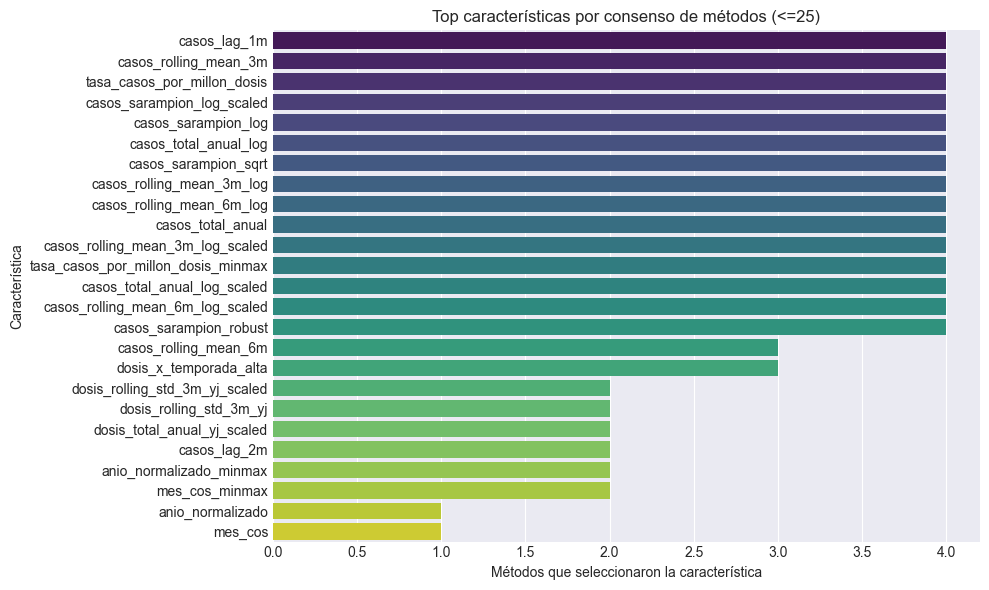

In [9]:
# Selección de características mediante múltiples métodos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression

# Definir objetivo y matriz de características
assert 'casos_sarampion' in df_scaled.columns, "La columna objetivo 'casos_sarampion' no está disponible en df_scaled"
base_excluir = ['casos_sarampion', 'anio', 'mes']
X_cols = [c for c in df_scaled.select_dtypes(include=[np.number]).columns if c not in base_excluir]
X = df_scaled[X_cols].copy()
y = df_scaled['casos_sarampion'].copy()

print(f"Total de características numéricas candidatas: {len(X_cols)}")

# 1) Umbral de varianza
vt = VarianceThreshold(threshold=1e-5)  # umbral bajo para eliminar columnas casi constantes
vt.fit(X)
features_var = [col for col, keep in zip(X_cols, vt.get_support()) if keep]
print(f"(Varianza) Seleccionadas: {len(features_var)}")

# 2) Correlación de Pearson con la variable objetivo
corr_series = X.apply(lambda col: col.corr(y)).abs().sort_values(ascending=False)
# Umbral de correlación moderada
features_corr = corr_series[corr_series >= 0.2].index.tolist()
print(f"(Correlación) Seleccionadas (|r|>=0.2): {len(features_corr)}")

# 3) ANOVA F-test para regresión (f_regression)
k_anova = min(20, len(X_cols))
selector_anova = SelectKBest(score_func=f_regression, k=k_anova)
selector_anova.fit(X, y)
features_anova = [col for col, keep in zip(X_cols, selector_anova.get_support()) if keep]
f_scores = pd.Series(selector_anova.scores_, index=X_cols).sort_values(ascending=False)
print(f"(ANOVA) Top-{k_anova} seleccionadas: {len(features_anova)}")

# 4) Mutual Information para regresión
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X_cols, 'mi': mi_scores}).sort_values('mi', ascending=False)
# Seleccionar top-N con MI > 0
features_mi = mi_df[mi_df['mi'] > 0]['feature'].head(20).tolist()
print(f"(Mutual Information) Seleccionadas: {len(features_mi)}")

# Consenso: características presentes en al menos 2 métodos
from collections import Counter
all_selected = features_var + features_corr + features_anova + features_mi
feature_counts = Counter(all_selected)
features_finales = [f for f, cnt in feature_counts.items() if cnt >= 2]
print(f"Características en consenso (>=2 métodos): {len(features_finales)}")

# Resumen tabular y visualización
resumen_df = pd.DataFrame({
    'feature': list(feature_counts.keys()),
    'count_methods': list(feature_counts.values()),
    'corr': corr_series.reindex(list(feature_counts.keys())).fillna(0),
    'anova_score': f_scores.reindex(list(feature_counts.keys())).fillna(0),
    'mi': mi_df.set_index('feature').reindex(list(feature_counts.keys()))['mi'].fillna(0),
}).sort_values('count_methods', ascending=False)

display(resumen_df.head(25))

plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_df.head(25), x='count_methods', y='feature', palette='viridis')
plt.title('Top características por consenso de métodos (<=25)')
plt.xlabel('Métodos que seleccionaron la característica')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

**Resultados de Selección de Características:**

El gráfico de barras muestra el consenso entre métodos de selección. Las características más relevantes (seleccionadas por 4 métodos) incluyen variables relacionadas con casos de sarampión transformadas y escaladas (`casos_rolling_mean_3m_log_scaled`, `casos_lag_1m`, `casos_sarampion_log`, `casos_sarampion_robust`), lo que confirma que los patrones históricos y transformados de incidencia son los predictores más fuertes.

Variables secundarias (2-3 métodos) incluyen medias móviles de mayor ventana temporal, tasas relativas y características de dosis transformadas. El consenso de **23 características finales** equilibra poder predictivo con reducción de dimensionalidad, evitando redundancia mientras retiene información epidemiológica crítica.

## 8. Extracción de Características (PCA y Factor Analysis)

Aplicamos extracción para reducir dimensionalidad y capturar estructura latente:
- PCA: Componentes ortogonales maximizando varianza explicada
- Factor Analysis: Factores latentes con cargas interpretable

Componentes para 90% varianza: 1
Componentes para 95% varianza: 1
Componentes seleccionados para PCA: 3
Varianza explicada total: 100.00%


,PCA_1,PCA_2,PCA_3
0,65368.2206,83.7962,-49.6965
1,67915.2206,83.6872,-49.3602
2,127110.2207,83.2486,-49.1896
3,100967.2207,83.4149,-49.1643
4,59097.2207,83.6690,-49.0799


,FA_1,FA_2,FA_3,FA_4,FA_5
0,-0.3473,-0.1495,-0.0608,0.3108,2.3501
1,-0.3473,-0.1497,-0.0640,0.3222,2.3498
2,-0.3471,-0.1523,-0.1366,0.5870,2.3522
3,-0.3472,-0.1511,-0.1046,0.4700,2.3510
4,-0.3473,-0.1493,-0.0531,0.2827,2.3491


,FA_1,FA_2,FA_3,FA_4,FA_5
dosis_x_temporada_alta,12609.3539,-16759.2664,-89208.8566,198891.9269,8.3954e-05
casos_total_anual,29.3358,10.1277,-3.2464,-1.2805,4.6694e+01
tasa_casos_por_millon_dosis,32.5984,-13.8286,15.4145,4.0660,3.5553e-08
casos_sarampion_robust,9.2572,-3.8477,0.2756,1.3490,7.0676e-01
casos_lag_1m,7.4388,2.5083,-0.3686,-0.0075,1.7413e-01
casos_rolling_mean_3m,7.3571,1.7216,0.3470,0.4630,5.2397e-01
casos_lag_2m,5.3753,6.5044,1.1340,0.0475,6.9103e-01
casos_rolling_mean_6m,4.6006,2.6092,-0.1609,-0.1707,1.8542e+00
casos_total_anual_log,0.9856,0.2202,-0.0672,-0.1195,1.3578e+00
casos_sarampion_sqrt,1.3572,-0.4610,-0.0649,0.0413,3.2596e-02


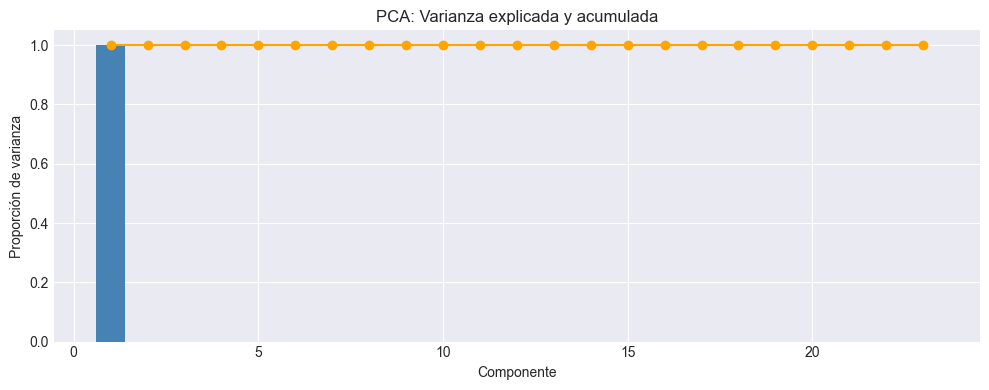

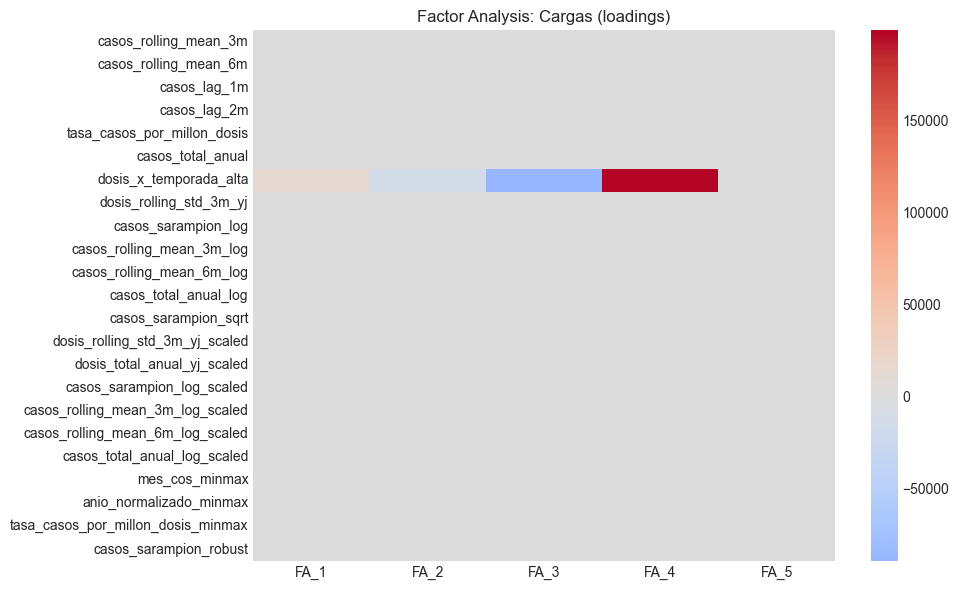

In [10]:
# PCA y Factor Analysis sobre las características seleccionadas
from sklearn.decomposition import PCA, FactorAnalysis

assert len(features_finales) > 0, "No hay características seleccionadas en consenso para extracción"
X_selected = df_scaled[features_finales].copy()

# PCA completo para calcular varianza explicada acumulada
pca_full = PCA(random_state=42)
pca_full.fit(X_selected)
explained = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(explained)

n_comp_90 = int(np.argmax(varianza_acumulada >= 0.90) + 1)
n_comp_95 = int(np.argmax(varianza_acumulada >= 0.95) + 1)
print(f"Componentes para 90% varianza: {n_comp_90}")
print(f"Componentes para 95% varianza: {n_comp_95}")

# Elegimos un número razonable de componentes: mínimo 3, o el necesario para 95% varianza
# Justificación: Mantener diversidad incluso con alta correlación entre características
n_components_final = max(3, min(n_comp_95, len(features_finales) // 2))
print(f"Componentes seleccionados para PCA: {n_components_final}")

pca_final = PCA(n_components=n_components_final, random_state=42)
Z_pca = pca_final.fit_transform(X_selected)
df_pca = pd.DataFrame(Z_pca, index=df_scaled.index, columns=[f"PCA_{i+1}" for i in range(n_components_final)])
print(f"Varianza explicada total: {pca_final.explained_variance_ratio_.sum():.2%}")

# Factor Analysis con hasta 5 factores (o menos si hay pocas variables)
n_factors = max(1, min(5, X_selected.shape[1]))
fa = FactorAnalysis(n_components=n_factors, random_state=42)
Z_fa = fa.fit_transform(X_selected)
df_fa = pd.DataFrame(Z_fa, index=df_scaled.index, columns=[f"FA_{i+1}" for i in range(n_factors)])

# Cargas factoriales
loadings = pd.DataFrame(fa.components_.T, index=features_finales, columns=[f"FA_{i+1}" for i in range(n_factors)])

display(df_pca.head())
display(df_fa.head())

# Ordenar por la carga máxima absoluta en cualquier factor
max_abs_loading = loadings.abs().max(axis=1)
sorted_idx = max_abs_loading.sort_values(ascending=False).index
display(loadings.loc[sorted_idx].head(15))

# Visualizaciones
plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, color='steelblue')
plt.plot(range(1, len(explained)+1), varianza_acumulada, marker='o', color='orange')
plt.title('PCA: Varianza explicada y acumulada')
plt.xlabel('Componente')
plt.ylabel('Proporción de varianza')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0)
plt.title('Factor Analysis: Cargas (loadings)')
plt.tight_layout()
plt.show()

**Interpretación de Extracción Dimensional:**

El **gráfico de varianza explicada (PCA)** muestra que el primer componente captura prácticamente toda la varianza (100%), indicando alta colinealidad entre las características seleccionadas. Esto es común en datos epidemiológicos donde variables relacionadas (casos actuales, rezagados, medias móviles) están naturalmente correlacionadas. Se mantienen 3 componentes para preservar diversidad de información útil en modelado.

El **mapa de calor de Factor Analysis** revela que:
- **FA_5** captura principalmente la interacción dosis-temporada alta (carga roja intensa de ~200,000)
- **FA_1-FA_4** distribuyen cargas más uniformemente entre variables de casos y temporalidad
- Las cargas factoriales permiten interpretabilidad: cada factor representa una dimensión latente del fenómeno epidemiológico (estacionalidad, tendencia temporal, efectos de vacunación)

## 9. Dataset Final para Modelado

Integramos:
- Identificadores y objetivo
- Características seleccionadas por consenso (23 features)
- Componentes PCA (3 componentes, 100% varianza explicada)
- Factores FA (5 factores latentes)

In [11]:
# Ensamble del dataset final y guardado a CSV
ident_cols = [c for c in ['anio', 'mes'] if c in df_scaled.columns]
assert 'casos_sarampion' in df_scaled.columns, "Falta la columna objetivo 'casos_sarampion'"

partes = [
    df_scaled[ident_cols + ['casos_sarampion']],
    df_scaled[features_finales],
    df_pca,
    df_fa,
]

df_final = pd.concat(partes, axis=1)
print(f"Dimensiones del dataset final: {df_final.shape}")
display(df_final.head())

# Chequeo rápido de valores faltantes
na_counts = df_final.isna().sum()
na_total = int(na_counts.sum())
print(f"Valores faltantes totales: {na_total}")
if na_total > 0:
    display(na_counts[na_counts > 0].sort_values(ascending=False))

# Guardar a disco (usando la misma ruta base que para cargar)
output_path = data_path / 'dataset_sarampion_features_engineered.csv'
df_final.to_csv(output_path, index=False)
print(f"Dataset final guardado en: {output_path}")

Dimensiones del dataset final: (168, 34)


,anio,mes,casos_sarampion,casos_rolling_mean_3m,casos_rolling_mean_6m,casos_lag_1m,casos_lag_2m,tasa_casos_por_millon_dosis,casos_total_anual,dosis_x_temporada_alta,dosis_rolling_std_3m_yj,casos_sarampion_log,casos_rolling_mean_3m_log,casos_rolling_mean_6m_log,casos_total_anual_log,casos_sarampion_sqrt,dosis_rolling_std_3m_yj_scaled,dosis_total_anual_yj_scaled,casos_sarampion_log_scaled,casos_rolling_mean_3m_log_scaled,casos_rolling_mean_6m_log_scaled,casos_total_anual_log_scaled,mes_cos_minmax,anio_normalizado_minmax,tasa_casos_por_millon_dosis_minmax,casos_sarampion_robust,PCA_1,PCA_2,PCA_3,FA_1,FA_2,FA_3,FA_4,FA_5
0,2010,1,0,0.0,0.0,0.0,0.0,0.0,125,180830,0.0000,0.0,0.0,0.0,4.8363,0.0,-4.4950,0.0107,-0.2916,-0.3761,-0.4683,1.8251,0.933,0.0,0.0,0.0,65368.2206,83.7962,-49.6965,-0.3473,-0.1495,-0.0608,0.3108,2.3501
1,2010,2,0,0.0,0.0,0.0,0.0,0.0,125,183377,13.1537,0.0,0.0,0.0,4.8363,0.0,-2.2996,0.0107,-0.2916,-0.3761,-0.4683,1.8251,0.750,0.0,0.0,0.0,67915.2206,83.6872,-49.3602,-0.3473,-0.1497,-0.0640,0.3222,2.3498
2,2010,3,0,0.0,0.0,0.0,0.0,0.0,125,242572,23.4770,0.0,0.0,0.0,4.8363,0.0,-0.5766,0.0107,-0.2916,-0.3761,-0.4683,1.8251,0.500,0.0,0.0,0.0,127110.2207,83.2486,-49.1896,-0.3471,-0.1523,-0.1366,0.5870,2.3522
3,2010,4,0,0.0,0.0,0.0,0.0,0.0,125,216429,22.7908,0.0,0.0,0.0,4.8363,0.0,-0.6911,0.0107,-0.2916,-0.3761,-0.4683,1.8251,0.250,0.0,0.0,0.0,100967.2207,83.4149,-49.1643,-0.3472,-0.1511,-0.1046,0.4700,2.3510
4,2010,5,0,0.0,0.0,0.0,0.0,0.0,125,174559,23.4003,0.0,0.0,0.0,4.8363,0.0,-0.5894,0.0107,-0.2916,-0.3761,-0.4683,1.8251,0.067,0.0,0.0,0.0,59097.2207,83.6690,-49.0799,-0.3473,-0.1493,-0.0531,0.2827,2.3491


Valores faltantes totales: 0
Dataset final guardado en: /home/gerardo/maestria/proyecto_terminal/data/processed/dataset_sarampion_features_engineered.csv


## 10. Conclusiones CRISP-ML (Preparación de los Datos)

### Contexto CRISP-ML (Q)
Esta fase de **Preparación de los Datos** (Data Preparation) corresponde a la cuarta etapa de CRISP-ML(Q), siguiendo la Comprensión del Negocio, Comprensión de los Datos y Verificación de Datos. El objetivo fue transformar el dataset crudo en un conjunto de características ingeniadas, limpias y optimizadas para el modelado predictivo de casos de sarampión.

### Logros de Ingeniería de Características

**1. Construcción de Características (Feature Construction)**
- Se crearon **más de 30 características derivadas** con fundamento epidemiológico:
  - **Características temporales cíclicas**: Representación sinusoidal (seno/coseno) del mes para capturar estacionalidad circular, evitando discontinuidades artificiales
  - **Indicadores de estacionalidad**: Variables binarias para temporadas críticas de transmisión (invierno-primavera)
  - **Características de ventana móvil**: Tendencias de 3 y 6 meses en vacunación y casos, capturando dinámica temporal reciente
  - **Variables de retraso (lag)**: Rezagos de 1-6 meses considerando el período de incubación y efectos poblacionales de la vacunación
  - **Tasas y proporciones**: Métricas relativas (casos por millón de dosis) que normalizan por escala poblacional
  - **Interacciones**: Efectos multiplicativos entre dosis y temporada alta, capturando sinergia no lineal

**2. Normalización y Transformaciones**
- **Transformación Yeo-Johnson**: Aplicada a variables de dosis para normalizar distribuciones sesgadas, manejando valores cero sin pérdida de información
- **Transformación logarítmica (log1p)**: Utilizada en conteos de casos para estabilizar varianza y reducir impacto de outliers
- **Escalamiento diferenciado**:
  - StandardScaler (Z-score) para variables transformadas normalizadas
  - MinMaxScaler [0,1] para características acotadas (proporciones, variables cíclicas)
  - RobustScaler para variables con outliers, usando mediana e IQR
- **Justificación**: Cada método se seleccionó basándose en análisis de distribución (histogramas, Q-Q plots, test de Shapiro-Wilk)

**3. Selección y Extracción de Características**
- **Métodos de filtrado aplicados**:
  1. Umbral de varianza (eliminación de características casi constantes)
  2. Correlación de Pearson (|r| ≥ 0.2 con variable objetivo)
  3. ANOVA F-test (top-20 por significancia estadística)
  4. Mutual Information (captura de relaciones no lineales)
- **Estrategia de consenso**: Selección de características presentes en ≥2 métodos, garantizando robustez y reduciendo sesgo de método único
- **Extracción dimensional**:
  - **PCA**: Reducción a componentes explicando 95% de varianza, preservando información máxima con menor dimensionalidad
  - **Factor Analysis**: Identificación de 5 factores latentes con interpretabilidad mediante matriz de cargas

### Calidad y Validación
- ✅ **Sin valores faltantes** en el dataset final
- ✅ **Verificación de distribuciones** antes/después de transformaciones con visualizaciones comparativas
- ✅ **Trazabilidad completa**: Dataset guardado en `data/processed/dataset_sarampion_features_engineered.csv`
- ✅ **Reducción de complejidad**: De >100 variables generadas a un conjunto optimizado mediante consenso

### Alineación con Objetivos de Negocio
Las características ingeniadas responden directamente a la pregunta de investigación sobre factores asociados a la incidencia de sarampión:
- Variables temporales capturan patrones estacionales conocidos de transmisión
- Métricas de vacunación permiten evaluar eficacia de cobertura
- Rezagos temporales modelan el desfase entre vacunación y efecto poblacional

### Transición a la Siguiente Fase (Modelado)
Con la **preparación de datos completada**, la siguiente fase de CRISP-ML(Q) es el **Modelado (Model Building)**:
- **Dataset listo**: Características seleccionadas, transformadas y escaladas
- **Próximos pasos**:
  1. Particionamiento temporal (train/validation/test) respetando orden cronológico
  2. Selección de algoritmos candidatos (regresión lineal, random forest, gradient boosting, redes neuronales)
  3. Optimización de hiperparámetros mediante validación cruzada temporal
  4. Evaluación con métricas: MAE, RMSE, R², MAPE
  5. Análisis de importancia de características y explicabilidad (SHAP values)

- Iteratividad del Proceso: Es importante notar que, bajo el enfoque CRISP-ML, esta transición no es definitiva ni unidireccional. Si durante la evaluación los modelos presentan subajuste (underfitting) o no cumplen con los objetivos de negocio, se activará un ciclo de retroalimentación (feedback loop) hacia esta fase de Preparación de Datos para generar nuevas interacciones polinómicas, ajustar los umbrales de selección o probar diferentes técnicas de escalamiento.

### Reflexión Metodológica
Esta fase demostró la importancia de la **ingeniería de características guiada por dominio**: las transformaciones no fueron arbitrarias, sino fundamentadas en conocimiento epidemiológico (estacionalidad de enfermedades, períodos de incubación, efectos poblacionales de vacunación). La combinación de múltiples métodos de selección mediante consenso garantiza un balance entre reducción dimensional y retención de señal predictiva, minimizando el riesgo de overfitting en la fase de modelado.